# 19. Document Intelligence — Automated Loan Document Processing

## Banking Business Case

Loan applications require many documents:

- KTP / identity document
- salary slip
- bank statement
- NPWP
- employment letter
- loan application form

Traditional processing requires employees to:

```text
Open Document
     ↓
Read Document
     ↓
Find Important Fields
     ↓
Type Data into System
     ↓
Validate
     ↓
Review
```

This project demonstrates how **Document Intelligence** can automate the workflow:

```text
Loan Documents
      ↓
Document Ingestion
      ↓
OCR / Text Extraction
      ↓
Document Classification
      ↓
Field Extraction
      ↓
Validation
      ↓
Confidence Scoring
      ↓
Human Review
      ↓
Loan Processing System
```

> This notebook uses synthetic metadata and extracted-field data. It does not process real customer documents.

## 1. What is Document Intelligence?

Document Intelligence combines:

```text
OCR
+
Computer Vision
+
NLP
+
Information Extraction
+
Rules / Validation
+
Machine Learning
```

The objective is not simply to convert an image into text.

The real objective is:

> **Turn unstructured documents into structured, validated business data.**

## 2. Example Loan Document

Imagine a salary slip contains:

```text
Employee Name : Andi Santoso
Employee ID   : EMP00123
Employer      : PT Bank ABC
Period        : August 2026
Basic Salary  : Rp 12,000,000
Net Salary    : Rp 10,800,000
```

Document Intelligence converts this into:

```text
Customer_Name      = Andi Santoso
Employer           = PT Bank ABC
Monthly_Income     = 10,800,000
Document_Period    = August 2026
```

The structured data can then flow into a loan underwriting system.

## 3. End-to-End Architecture

```text
             Loan Application
                    ↓
             Document Upload
                    ↓
            File Validation
                    ↓
             Image / PDF OCR
                    ↓
         Document Classification
                    ↓
             Text Extraction
                    ↓
           Entity / Field Extraction
                    ↓
          Normalization & Validation
                    ↓
            Confidence Scoring
                    ↓
       ┌────────────┼────────────┐
       ↓            ↓            ↓
   Auto Pass    Human Review   Reject
       └────────────┼────────────┘
                    ↓
             Structured Data
                    ↓
             Loan Processing
                    ↓
               Monitoring
```

## 4. Project Objectives

The project objective is restated in one place: extract fields from submitted loan documents, check document quality, and decide which applications can be straight-through processed versus reviewed by a human.


This project answers:

1. What type of document was uploaded?
2. Can we extract the required fields?
3. How confident are we in the extracted values?
4. Are the extracted values valid?
5. Which documents can be processed automatically?
6. Which documents need human review?
7. How much manual processing can be reduced?
8. What controls are required for banking production?

## 5. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, re for text extraction rules, and Matplotlib/Seaborn for visualisation.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

docs = pd.read_csv(
    "loan_document_metadata.csv",
    parse_dates=["Document_Date"]
)

extracted = pd.read_csv(
    "loan_extracted_fields.csv"
)

rules = pd.read_csv(
    "document_validation_rules.csv"
)

print("Documents:", len(docs))
print("Extracted field records:", len(extracted))

display(docs.head())
display(extracted.head())
display(rules)
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


Documents: 1200
Extracted field records: 1000


,Document_ID,Customer_ID,Document_Type,Document_Date,Image_Quality_Score,OCR_Confidence,Fields_Extracted,Expected_Fields,File_Size_KB,Status
0,DOC0000001,C000063,Rekening Koran,2026-02-12,0.950,0.985,8,11,3699,INVALID
1,DOC0000002,C000533,KTP,2026-02-20,0.758,0.980,9,8,4127,VALID
2,DOC0000003,C000315,Rekening Koran,2024-08-15,0.745,0.980,5,10,3526,NEEDS_REVIEW
3,DOC0000004,C000248,Form Aplikasi,2025-05-12,0.809,0.882,4,9,839,VALID
4,DOC0000005,C000645,Form Aplikasi,2026-01-14,0.799,0.845,10,7,2357,VALID


,Document_ID,Customer_ID,NIK_Extracted,Customer_Name_Extracted,Employer_Extracted,Monthly_Income_Extracted,Account_Number_Extracted,Loan_Amount_Extracted,OCR_Confidence
0,DOC0001115,C000506,1712188267305844,ANDI SANTOSO,PT Maju Jaya,33433000.0,9258522692,336700000.0,0.902
1,DOC0000665,C000236,6046036920268097,Fajar Nugroho,CV Sejahtera,21917000.0,1399663032,115400000.0,0.901
2,DOC0000019,C000252,1589748703883202,BUDI WIJAYA,PT Nusantara,20043000.0,4678134857,794000000.0,0.952
3,DOC0000026,C000186,8080261289755750,Fajar Nugroho,PT Maju Jaya,7340000.0,9354086163,520100000.0,0.716
4,DOC0001106,C000585,9250303516857684,Fajar Nugroho,PT Nusantara,5681000.0,8089803311,180200000.0,0.797


,Field,Rule,Description
0,NIK,16 digits,Must contain exactly 16 numeric digits
1,Monthly Income,> 0,Must be positive
2,Loan Amount,> 0,Must be positive
3,OCR Confidence,>= 0.85,Auto-processing threshold
4,Field Completeness,>= 0.80,Minimum extracted-field ratio


## 6. Dataset Dictionary

The document/application table is documented — submitted document types, extracted field values, quality and validation flags — defining exactly what the automated pipeline reads.


In [2]:
dictionary = pd.DataFrame({
    "Field": [
        "Document_ID","Customer_ID","Document_Type",
        "Image_Quality_Score","OCR_Confidence",
        "Fields_Extracted","Expected_Fields",
        "NIK_Extracted","Customer_Name_Extracted",
        "Employer_Extracted","Monthly_Income_Extracted",
        "Account_Number_Extracted","Loan_Amount_Extracted"
    ],
    "Description": [
        "Unique document identifier",
        "Synthetic customer identifier",
        "Document category",
        "Image quality score",
        "OCR confidence score",
        "Number of extracted fields",
        "Number of expected fields",
        "Extracted identity number",
        "Extracted customer name",
        "Extracted employer",
        "Extracted monthly income",
        "Extracted account number",
        "Extracted requested loan amount"
    ]
})
display(dictionary)

,Field,Description
0,Document_ID,Unique document identifier
1,Customer_ID,Synthetic customer identifier
2,Document_Type,Document category
3,Image_Quality_Score,Image quality score
4,OCR_Confidence,OCR confidence score
5,Fields_Extracted,Number of extracted fields
6,Expected_Fields,Number of expected fields
7,NIK_Extracted,Extracted identity number
8,Customer_Name_Extracted,Extracted customer name
9,Employer_Extracted,Extracted employer


## 7. Data Quality Assessment

Missing documents, missing extracted fields and inconsistent values are checked. These are precisely the failure modes that block straight-through processing and force manual review.


In [3]:
print("Missing values:")
display(docs.isna().sum().to_frame("Missing"))

print("Document types:")
display(docs["Document_Type"].value_counts().to_frame("Documents"))

print("Status:")
display(docs["Status"].value_counts().to_frame("Documents"))

Missing values:


,Missing
Document_ID,0
Customer_ID,0
Document_Type,0
Document_Date,0
Image_Quality_Score,0
OCR_Confidence,0
Fields_Extracted,0
Expected_Fields,0
File_Size_KB,0
Status,0


Document types:


,Documents
Document_Type,
KTP,250
Slip Gaji,232
Rekening Koran,228
Surat Kerja,200
Form Aplikasi,164
NPWP,126


Status:


,Documents
Status,
VALID,956
NEEDS_REVIEW,165
INVALID,79


## 8. Document Ingestion

In production, documents can arrive through:

```text
Mobile App
Web Application
Branch Scanner
Email
API
Document Management System
```

The ingestion layer should validate:

- file type,
- file size,
- corrupted files,
- duplicate documents,
- malware/security controls,
- document ID,
- customer/application ID.

A production pipeline should never send arbitrary files directly into OCR.

## 9. Document Classification

The system first identifies the document type.

Examples:

```text
Image → KTP
PDF   → Salary Slip
Image → Bank Statement
PDF   → Employment Letter
```

Possible approaches:

### Rule-based

Filename / template / keywords.

### Machine Learning

Text or metadata classifier.

### Computer Vision

Image classification.

### Multimodal model

Image + text + layout.

For this project, document type is supplied as synthetic metadata.

Saved: output/9-document-classification.png


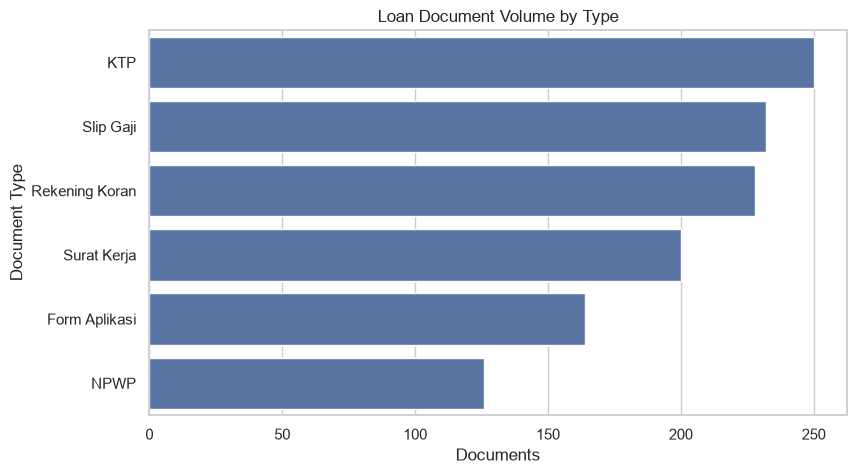

In [4]:
plt.figure(figsize=(9,5))
sns.countplot(
    data=docs,
    y="Document_Type",
    order=docs["Document_Type"].value_counts().index
)
plt.title("Loan Document Volume by Type")
plt.xlabel("Documents")
plt.ylabel("Document Type")
save_plot("9-document-classification.png")
plt.show()

## 10. OCR Layer

OCR converts:

```text
Image / PDF
     ↓
Machine-readable text
```

Example:

```text
"KTP
Nama: Andi Santoso
NIK: 327xxxxxxxxxxxxx"
```

Common production technologies include:

- Tesseract
- cloud OCR services
- document AI APIs
- multimodal vision models

OCR quality depends on:

- resolution,
- blur,
- rotation,
- lighting,
- handwriting,
- document layout,
- language.

## 11. OCR Confidence

OCR systems commonly provide confidence scores.

Example:

```text
NIK       → 0.99
Name      → 0.97
Employer  → 0.94
Salary    → 0.71
```

A field-level confidence score is often more useful than only a document-level score.

A low-confidence critical field can trigger human review.

Saved: output/11-ocr-confidence.png


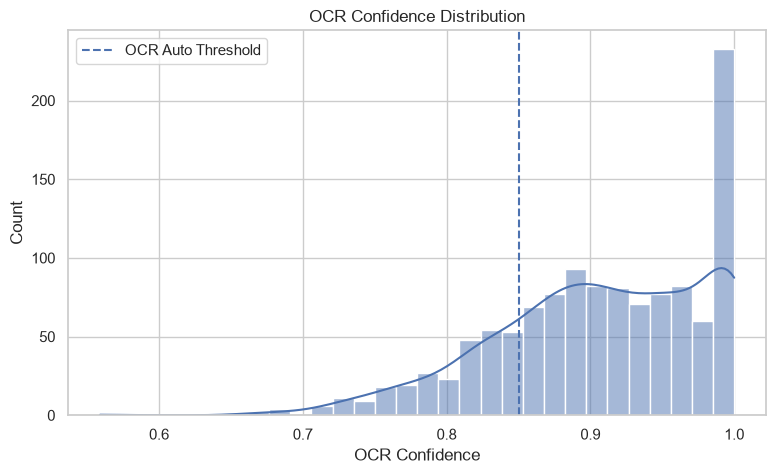

In [5]:
plt.figure(figsize=(9,5))
sns.histplot(docs["OCR_Confidence"], bins=30, kde=True)
plt.axvline(.85, ls="--", label="OCR Auto Threshold")
plt.title("OCR Confidence Distribution")
plt.xlabel("OCR Confidence")
plt.legend()
save_plot("11-ocr-confidence.png")
plt.show()

## 12. Field Extraction

After OCR, the system extracts structured entities.

Examples:

```text
NIK
Name
Date of Birth
Employer
Income
Account Number
Loan Amount
```

Approaches include:

- regular expressions,
- keyword + layout rules,
- NER,
- template extraction,
- transformer models,
- multimodal models.

In [6]:
# Example regex patterns for simple extraction

nik_pattern = r"\b\d{16}\b"
amount_pattern = r"(?:Rp\s*)?([0-9\.]+)"

example_text = '''
Nama: Andi Santoso
NIK: 3271234567890123
Gaji: Rp 12.000.000
'''

nik = re.findall(nik_pattern, example_text)
amount = re.findall(amount_pattern, example_text)

print("Extracted NIK:", nik)
print("Extracted amounts:", amount)

Extracted NIK: ['3271234567890123']
Extracted amounts: ['3271234567890123', '12.000.000']


## 13. Synthetic Extracted Fields

The dataset represents the output of an extraction engine.

In a real project:

```text
Document Image
      ↓
OCR
      ↓
Layout / NLP / CV
      ↓
Extracted Fields
```

The notebook starts from the extracted-field layer so the focus can remain on downstream document intelligence.

In [7]:
display(extracted.head(10))

,Document_ID,Customer_ID,NIK_Extracted,Customer_Name_Extracted,Employer_Extracted,Monthly_Income_Extracted,Account_Number_Extracted,Loan_Amount_Extracted,OCR_Confidence
0,DOC0001115,C000506,1712188267305844,ANDI SANTOSO,PT Maju Jaya,33433000.0,9258522692,336700000.0,0.902
1,DOC0000665,C000236,6046036920268097,Fajar Nugroho,CV Sejahtera,21917000.0,1399663032,115400000.0,0.901
2,DOC0000019,C000252,1589748703883202,BUDI WIJAYA,PT Nusantara,20043000.0,4678134857,794000000.0,0.952
3,DOC0000026,C000186,8080261289755750,Fajar Nugroho,PT Maju Jaya,7340000.0,9354086163,520100000.0,0.716
4,DOC0001106,C000585,9250303516857684,Fajar Nugroho,PT Nusantara,5681000.0,8089803311,180200000.0,0.797
5,DOC0000857,C000335,4123618000715610,EKO SAPUTRA,PT Digital Indonesia,19409000.0,3895191179,541200000.0,0.818
6,DOC0000421,C000152,7193330213868599,EKO SAPUTRA,PT Digital Indonesia,34360000.0,4020380644,389400000.0,1.000
7,DOC0001060,C000022,1837694452173065,ANDI SANTOSO,PT Nusantara,9008000.0,8379732389,435500000.0,0.846
8,DOC0001141,C000187,3002701248915469,BUDI WIJAYA,CV Sejahtera,31060000.0,5154619295,328400000.0,0.866
9,DOC0001182,C000420,5323330140797040,DEWI PRATAMA,PT Maju Jaya,42763000.0,7572612411,591400000.0,1.000


## 14. Field Completeness

Define:

```text
Field Completeness =
Fields Extracted / Expected Fields
```

Example:

```text
9 fields extracted
10 expected fields

Completeness = 90%
```

Low completeness should increase the probability of manual review.

In [8]:
docs["Field_Completeness"] = (
    docs["Fields_Extracted"] /
    docs["Expected_Fields"]
).clip(0,1)

display(
    docs["Field_Completeness"]
    .describe()
    .to_frame("Value")
)

,Value
count,1200.000000
mean,0.752108
std,0.284385
min,0.000000
25%,0.600000
50%,0.833333
75%,1.000000
max,1.000000


## 15. Image Quality Assessment

The distribution of image-quality scores (blur, brightness, resolution proxies) is reviewed. Poor scans cannot be extracted reliably and should be routed back to the applicant instead of silently failing downstream.


Saved: output/15-image-quality-assessment.png


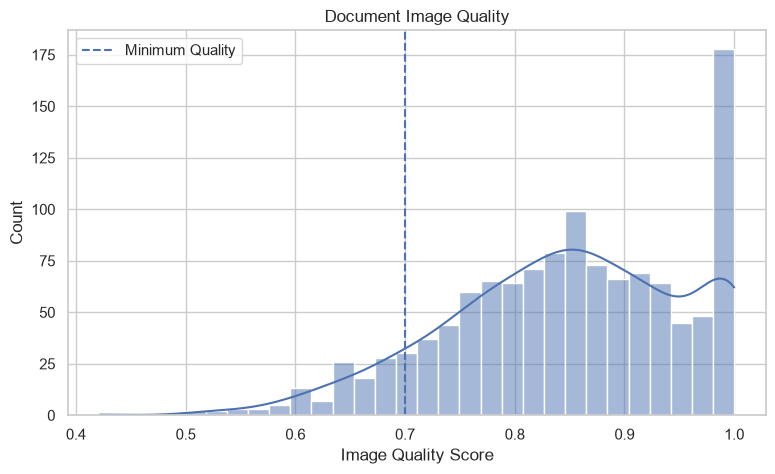

In [9]:
plt.figure(figsize=(9,5))
sns.histplot(docs["Image_Quality_Score"],bins=30,kde=True)
plt.axvline(.70,ls="--",label="Minimum Quality")
plt.title("Document Image Quality")
plt.xlabel("Image Quality Score")
plt.legend()
save_plot("15-image-quality-assessment.png")
plt.show()

## 16. Validation Rules

Extracted values should not automatically become trusted banking data.

Examples:

### NIK

```text
Exactly 16 digits
```

### Income

```text
> 0
```

### Loan Amount

```text
> 0
```

### OCR Confidence

```text
>= 0.85
```

### Completeness

```text
>= 0.80
```

In [10]:
def validate_nik(x):
    return bool(re.fullmatch(r"\d{16}", str(x)))

def validate_positive(x):
    try:
        return float(x) > 0
    except:
        return False

extracted["NIK_Valid"] = extracted["NIK_Extracted"].apply(validate_nik)
extracted["Income_Valid"] = extracted["Monthly_Income_Extracted"].apply(validate_positive)
extracted["Loan_Amount_Valid"] = extracted["Loan_Amount_Extracted"].apply(validate_positive)

display(
    extracted[
        ["NIK_Valid","Income_Valid","Loan_Amount_Valid"]
    ].mean().to_frame("Validation Rate")
)

,Validation Rate
NIK_Valid,1.0
Income_Valid,1.0
Loan_Amount_Valid,1.0


## 17. Cross-Document Validation

The strongest validation does not look at a single document.

Example:

```text
KTP
Name = Andi Santoso

Salary Slip
Name = Andi Santoso

Bank Statement
Name = Andi Santoso
```

We can compare extracted fields across documents.

Potential controls:

```text
Name consistency
NIK consistency
Employer consistency
Income consistency
Account ownership
Document date consistency
```

This is important for loan processing.

In [11]:
# Illustrative customer-level consistency check
name_consistency = (
    extracted.groupby("Customer_ID")["Customer_Name_Extracted"]
    .nunique()
    .reset_index(name="Unique_Names")
)

name_consistency["Name_Consistent"] = (
    name_consistency["Unique_Names"] == 1
)

display(name_consistency.head(10))

,Customer_ID,Unique_Names,Name_Consistent
0,C000001,1,True
1,C000003,1,True
2,C000004,2,False
3,C000005,1,True
4,C000007,2,False
5,C000008,2,False
6,C000009,2,False
7,C000010,1,True
8,C000013,4,False
9,C000014,2,False


## 18. Document Confidence Score

Combine several signals:

```text
Document Confidence
=
OCR Confidence
+ Image Quality
+ Field Completeness
+ Validation Rate
```

Illustrative weighted score:

```text
35% OCR
25% Image Quality
25% Completeness
15% Field Validation
```

In [12]:
validation_rate = (
    extracted[["NIK_Valid","Income_Valid","Loan_Amount_Valid"]]
    .mean(axis=1)
)

# Join representative extraction confidence to document-level metadata
doc_score = docs.merge(
    extracted.groupby("Document_ID")["OCR_Confidence"].mean().rename("Extracted_OCR_Confidence"),
    left_on="Document_ID",
    right_index=True,
    how="left"
)

doc_score["Extracted_OCR_Confidence"] = (
    doc_score["Extracted_OCR_Confidence"]
    .fillna(doc_score["OCR_Confidence"])
)

doc_score["Document_Confidence"] = (
    .35 * doc_score["Extracted_OCR_Confidence"] +
    .25 * doc_score["Image_Quality_Score"] +
    .25 * doc_score["Field_Completeness"] +
    .15 * doc_score["OCR_Confidence"]
).clip(0,1)

display(
    doc_score[
        ["Document_ID","Document_Type","Document_Confidence"]
    ].head(10)
)

,Document_ID,Document_Type,Document_Confidence
0,DOC0000001,Rekening Koran,0.911818
1,DOC0000002,KTP,0.897650
2,DOC0000003,Rekening Koran,0.801250
3,DOC0000004,Form Aplikasi,0.719011
4,DOC0000005,Form Aplikasi,0.926500
5,DOC0000006,Slip Gaji,0.946133
6,DOC0000007,Slip Gaji,0.961500
7,DOC0000008,NPWP,0.903850
8,DOC0000009,Rekening Koran,0.828222
9,DOC0000010,KTP,0.940750


## 19. Human-in-the-Loop Decision

A banking document pipeline should not blindly automate everything.

Example:

```text
Confidence >= 0.90
→ Straight-through processing

0.75–0.90
→ Human review

< 0.75
→ Reprocess / reject
```

Thresholds should be calibrated using real validation data and business risk.

In [13]:
def processing_decision(score):
    if score >= .90:
        return "Auto Process"
    elif score >= .75:
        return "Human Review"
    else:
        return "Reprocess / Reject"

doc_score["Processing_Decision"] = (
    doc_score["Document_Confidence"]
    .apply(processing_decision)
)

display(
    doc_score["Processing_Decision"]
    .value_counts()
    .to_frame("Documents")
)

,Documents
Processing_Decision,
Human Review,690
Auto Process,370
Reprocess / Reject,140


## 20. Processing Decision Distribution

The counts of auto-approved, auto-rejected and manual-review decisions are visualised. This distribution is the headline business result: it shows how much workload document automation removes from staff.


Saved: output/20-processing-decision-distribution.png


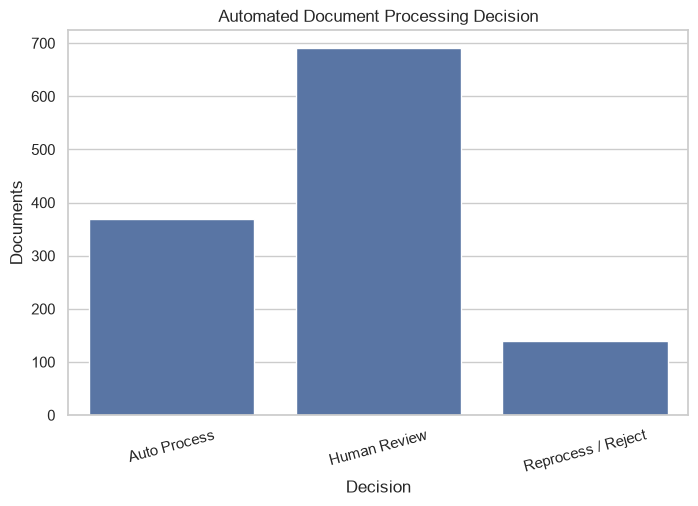

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=doc_score,
    x="Processing_Decision",
    order=["Auto Process","Human Review","Reprocess / Reject"]
)
plt.title("Automated Document Processing Decision")
plt.xlabel("Decision")
plt.ylabel("Documents")
plt.xticks(rotation=15)
save_plot("20-processing-decision-distribution.png")
plt.show()

## 21. Straight-Through Processing Rate

A key operational KPI is:

```text
STP Rate =
Automatically Processed Documents
----------------------------------
All Eligible Documents
```

Higher STP can reduce manual workload, but only if quality remains acceptable.

In [15]:
stp_rate=(
    doc_score["Processing_Decision"]
    .eq("Auto Process")
    .mean()
)

review_rate=(
    doc_score["Processing_Decision"]
    .eq("Human Review")
    .mean()
)

print("STP Rate:",round(stp_rate*100,2),"%")
print("Human Review Rate:",round(review_rate*100,2),"%")

STP Rate: 30.83 %
Human Review Rate: 57.5 %


## 22. Human Review Queue

The review queue should prioritize:

- low confidence,
- critical field failures,
- inconsistent customer information,
- poor image quality,
- expired documents,
- suspicious alterations.

A reviewer should see the document image together with:

```text
Extracted Value
Confidence
Validation Result
Expected Value
Reason for Review
```

In [16]:
review_queue = doc_score[
    doc_score["Processing_Decision"]=="Human Review"
].copy()

review_queue["Review_Reason"] = np.select(
    [
        review_queue["Field_Completeness"] < .80,
        review_queue["Image_Quality_Score"] < .70,
        review_queue["Extracted_OCR_Confidence"] < .85
    ],
    [
        "Low field completeness",
        "Poor image quality",
        "Low OCR confidence"
    ],
    default="Borderline confidence"
)

display(
    review_queue[
        [
            "Document_ID","Customer_ID","Document_Type",
            "Document_Confidence","Field_Completeness",
            "Image_Quality_Score","Extracted_OCR_Confidence",
            "Review_Reason"
        ]
    ].head(25)
)

,Document_ID,Customer_ID,Document_Type,Document_Confidence,Field_Completeness,Image_Quality_Score,Extracted_OCR_Confidence,Review_Reason
1,DOC0000002,C000533,KTP,0.897650,1.000000,0.758,0.889000,Borderline confidence
2,DOC0000003,C000315,Rekening Koran,0.801250,0.500000,0.745,0.980000,Low field completeness
8,DOC0000009,C000308,Rekening Koran,0.828222,0.888889,0.658,0.883000,Poor image quality
11,DOC0000012,C000285,KTP,0.812550,0.700000,0.816,0.862000,Low field completeness
13,DOC0000014,C000253,KTP,0.796783,0.600000,0.740,0.915667,Low field completeness
14,DOC0000015,C000183,Rekening Koran,0.821375,0.625000,0.835,0.946500,Low field completeness
15,DOC0000016,C000142,Rekening Koran,0.844250,1.000000,0.789,0.794000,Low OCR confidence
17,DOC0000018,C000462,KTP,0.880100,1.000000,0.717,0.920000,Borderline confidence
18,DOC0000019,C000243,KTP,0.771407,0.571429,0.684,0.952000,Low field completeness
19,DOC0000020,C000309,Rekening Koran,0.838722,0.888889,0.604,0.931000,Poor image quality


## 23. Document Classification Quality

If document classification is ML-based, evaluate:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Example error:

```text
Salary Slip → Classified as Bank Statement
```

This can cause incorrect downstream extraction rules.

## 24. Field Extraction Quality

For extracted fields, use field-level evaluation.

### Numeric fields

```text
Exact Match
Absolute Error
Relative Error
```

### Text fields

```text
Exact Match
Normalized Match
Similarity
```

### Critical identifiers

For NIK / account number, exact correctness is usually more important than approximate similarity.

## 25. Example Loan Application Data Flow

```text
Applicant
   ↓
Uploads 5 Documents
   ↓
Document Classifier
   ↓
KTP → Identity Fields
Salary Slip → Income Fields
Bank Statement → Account / Transaction Fields
NPWP → Tax Identity
Employment Letter → Employer Fields
   ↓
Cross-document Validation
   ↓
Structured Loan Application
   ↓
Credit Scoring / Underwriting
```

Document Intelligence is therefore an upstream component of loan underwriting.

## 26. Business KPIs

Recommended KPIs:

### Automation

- STP rate
- Manual review rate
- Reprocessing rate

### Accuracy

- OCR accuracy
- document classification F1
- field extraction accuracy
- critical-field accuracy

### Operations

- average processing time
- documents per reviewer
- queue backlog
- SLA compliance

### Risk

- false extraction rate
- false validation rate
- fraud / tampering detection rate
- rejected document rate

## 27. Before vs After

### Traditional

```text
Customer
  ↓
Branch / Officer
  ↓
Manual Reading
  ↓
Manual Data Entry
  ↓
Manual Validation
  ↓
Loan Processing
```

### Automated

```text
Customer
  ↓
Digital Upload
  ↓
OCR + Document AI
  ↓
Extraction
  ↓
Validation
  ↓
Confidence Check
  ↓
Human Review if Needed
  ↓
Loan Processing
```

The target is not necessarily **100% automation**.

The target is:

> **Safe automation of high-confidence cases while routing uncertain cases to humans.**

## 28. Advanced Extensions

This project can be extended with:

### Computer Vision

- document tampering detection,
- signature detection,
- face/document consistency,
- image quality classification.

### NLP

- named entity recognition,
- document summarization,
- clause extraction.

### LLM / Multimodal AI

- complex document understanding,
- layout-aware extraction,
- question answering over documents.

### Fraud Detection

Detect:

- altered salary,
- inconsistent fonts,
- suspicious metadata,
- duplicate documents,
- synthetic documents.

### RAG

Create a document knowledge layer for:

```text
Loan policy
Product terms
Credit policy
Required document checklist
```

## 29. Production Architecture

```text
                    ┌───────────────┐
                    │ Loan Applicant│
                    └───────┬───────┘
                            ↓
                     Document Upload
                            ↓
                  Object Storage / DMS
                            ↓
                    Security Scanning
                            ↓
                       OCR / CV
                            ↓
                 Document Classification
                            ↓
                    Field Extraction
                            ↓
                 Normalization / Rules
                            ↓
                   Confidence Scoring
                            ↓
             ┌──────────────┼──────────────┐
             ↓              ↓              ↓
          Auto Pass     Human Review    Reject
             └──────────────┼──────────────┘
                            ↓
                     Loan Workflow
                            ↓
                    Audit / Monitoring
```

Production components may include:

```text
Object Storage
OCR Engine
Document AI
Model Serving
Rules Engine
Workflow Engine
API
Data Warehouse
Audit Store
Monitoring
```

## 30. Security and Governance

Loan documents contain sensitive customer information.

Production controls should include:

- encryption at rest,
- encryption in transit,
- role-based access,
- least privilege,
- masking of sensitive identifiers,
- retention policy,
- audit logging,
- secure deletion,
- model/version tracking,
- human review controls,
- regulatory compliance.

Synthetic data is used in this notebook so that no real customer document is exposed.

## 31. Common Mistakes

1. Treating OCR output as ground truth.
2. Ignoring field-level confidence.
3. No validation rules.
4. No human review.
5. Automatically accepting low-confidence extraction.
6. Using only document-level confidence.
7. Ignoring cross-document consistency.
8. No audit trail.
9. No document versioning.
10. No monitoring of OCR drift.
11. No security controls for sensitive documents.
12. Measuring automation rate without measuring accuracy.

## 32. Final Executive Summary

### Business Question

> **How can the bank automatically process loan documents while maintaining data quality and control?**

### End-to-End

```text
Document Upload
      ↓
File Validation
      ↓
OCR
      ↓
Document Classification
      ↓
Field Extraction
      ↓
Normalization
      ↓
Validation
      ↓
Confidence Scoring
      ↓
Auto Process / Human Review / Reject
      ↓
Structured Loan Data
      ↓
Loan Underwriting
      ↓
Monitoring & Audit
```

### Key Concept

Document Intelligence is more than OCR:

```text
OCR
→ What text is in the document?

Document Intelligence
→ What does the document mean,
  what fields matter,
  are they valid,
  and can the bank safely use them?
```

This makes Document Intelligence a natural upstream capability for **digital lending, KYC, onboarding, credit underwriting, and loan operations**.

## 33. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [17]:
doc_score.to_csv(OUTPUT_DIR / "document_scoring.csv", index=False)
print("Saved:", OUTPUT_DIR / "document_scoring.csv")
review_queue.to_csv(OUTPUT_DIR / "human_review_queue.csv", index=False)
print("Saved:", OUTPUT_DIR / "human_review_queue.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/document_scoring.csv
Saved: output/human_review_queue.csv
  output/11-ocr-confidence.png
  output/15-image-quality-assessment.png
  output/20-processing-decision-distribution.png
  output/9-document-classification.png
  output/document_scoring.csv
  output/human_review_queue.csv
